 Name: Maan Lo
 ID: 2511765
 Assignment: GA3 (Part 4)
# Part 4: Data Visualization & Machine Learning
### Student Performance Analysis & Prediction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Task 1 — Data Exploration with Pandas

In [2]:
# Load dataset
df = pd.read_csv("students.csv")

# 1) Print first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [3]:
# 2) Shape and data types
print("Shape (rows x columns):", df.shape)
print("\nData types:")
print(df.dtypes)

Shape (rows x columns): (15, 9)

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [4]:
# 3) Summary statistics for all numeric columns
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2

In [5]:
# 4) Number of students who passed and failed
print("Pass / Fail Count:")
print(df['passed'].value_counts())

Pass / Fail Count:
passed
1    9
0    6
Name: count, dtype: int64


In [6]:
# 5) Average score per subject between passing vs failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage scores — Passing students:")
print(df[df['passed'] == 1][subject_cols].mean().round(2))

print("\nAverage scores — Failing students:")
print(df[df['passed'] == 0][subject_cols].mean().round(2))


Average scores — Passing students:
math       78.22
science    78.56
english    79.11
history    73.44
pe         86.00
dtype: float64

Average scores — Failing students:
math       45.17
science    49.00
english    46.83
history    48.33
pe         58.00
dtype: float64


In [7]:
# 6) Student with highest overall average across all 5 subjects
subject_cols = ['math', 'science', 'english', 'history', 'pe']
temp_avg = df[subject_cols].mean(axis=1)
top_idx  = temp_avg.idxmax()
print("\nTop student by subject average:")
print(f"  Name    : {df.loc[top_idx, 'name']}")
print(f"  Average : {temp_avg[top_idx]:.2f}")


Top student by subject average:
  Name    : Diana
  Average : 94.00


## Task 2 — Data Visualization with Matplotlib

In [8]:
# Add avg_score column to df (used in the scatter plot below)
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

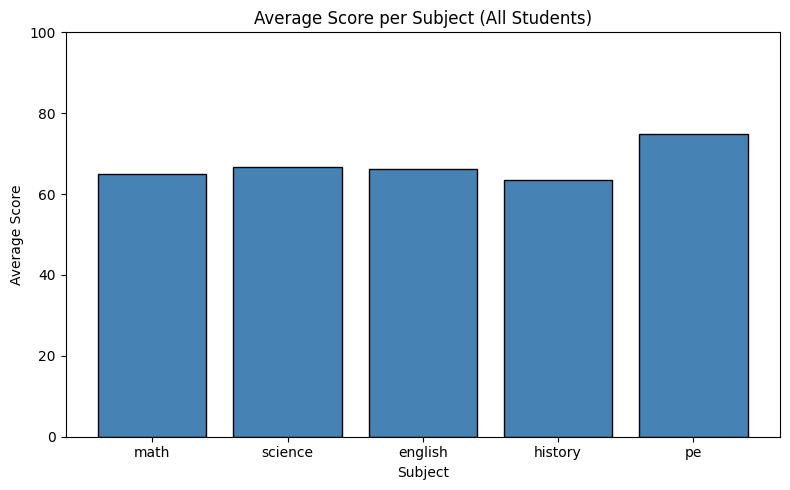

Saved: plot1_bar.png


In [9]:
# Plot1 — Bar Chart: average score per subject across all students
avg_per_subject = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_per_subject.index, avg_per_subject.values,
        color='steelblue', edgecolor='black')
plt.title("Average Score per Subject (All Students)")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("plot1_bar.png", dpi=150)
plt.show()
print("Saved: plot1_bar.png")

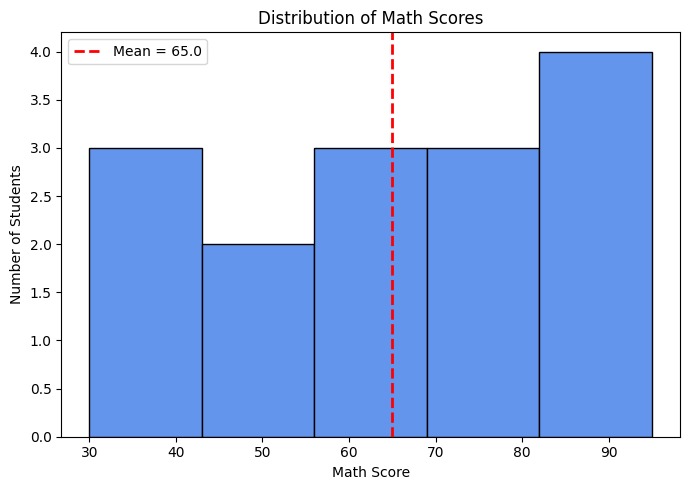

Saved: plot2_hist.png


In [10]:
# Plot2 — Histogram: distribution of math scores with labelled mean line
mean_math = df['math'].mean()

plt.figure(figsize=(7, 5))
plt.hist(df['math'], bins=5, color='cornflowerblue', edgecolor='black')
# Dashed vertical line at mean — label= makes it appear in the legend
plt.axvline(mean_math, color='red', linestyle='dashed', linewidth=2,
            label=f'Mean = {mean_math:.1f}')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_hist.png", dpi=150)
plt.show()
print("Saved: plot2_hist.png")

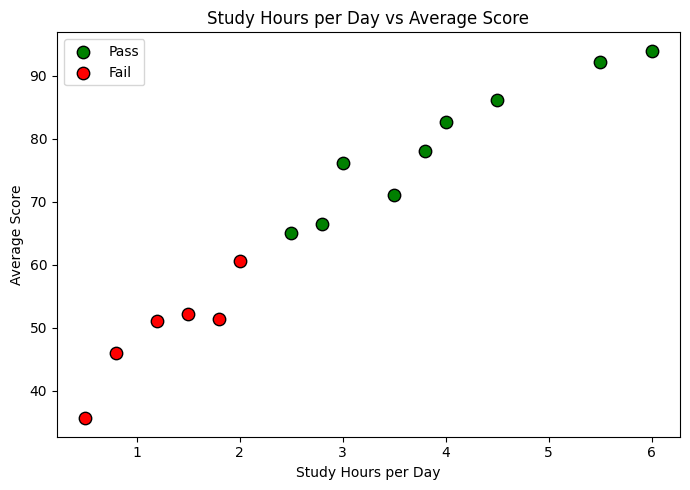

Saved: plot3_scatter.png


In [11]:
# Plot3 — Scatter Plot: study hours vs avg score, coloured by pass/fail
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure(figsize=(7, 5))
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
            color='green', label='Pass', s=80, edgecolors='black')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
            color='red',   label='Fail', s=80, edgecolors='black')
plt.title("Study Hours per Day vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png", dpi=150)
plt.show()
print("Saved: plot3_scatter.png")

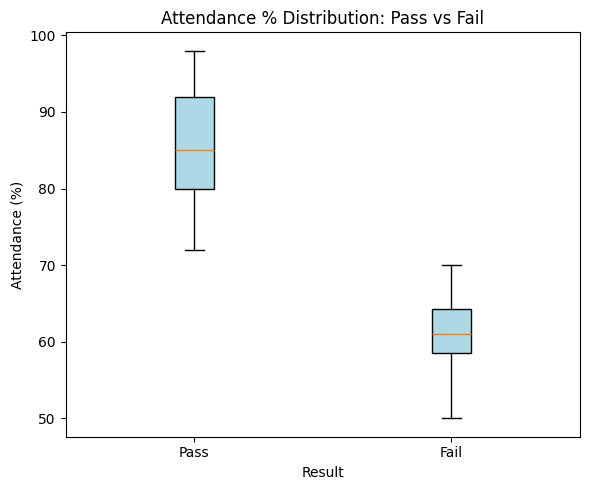

Saved: plot4_box.png


In [12]:
# Plot4 — Box Plot: attendance_pct distribution for Pass vs Fail students
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(6, 5))
plt.boxplot([pass_attendance, fail_attendance],
            tick_labels=['Pass', 'Fail'],   # tick_labels avoids deprecation warning
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title("Attendance % Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance (%)")
plt.tight_layout()
plt.savefig("plot4_box.png", dpi=150)
plt.show()
print("Saved: plot4_box.png")

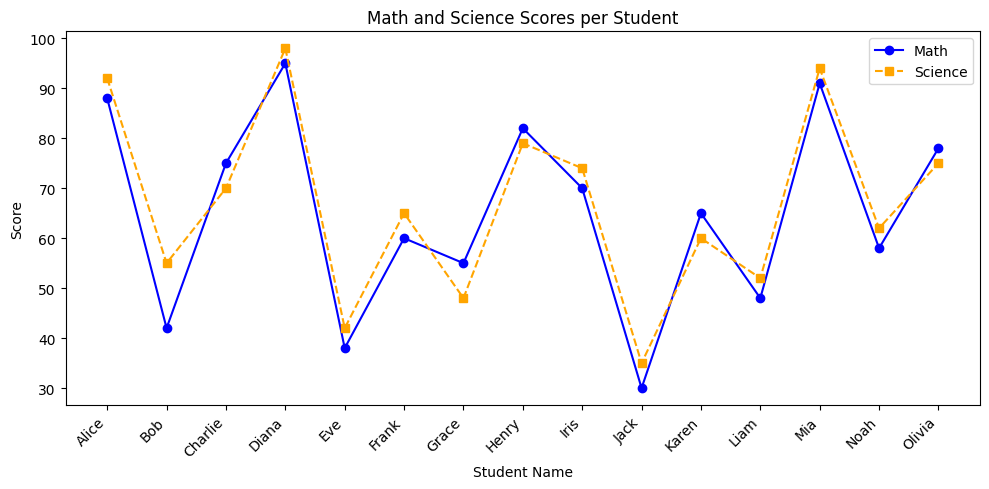

Saved: plot5_line.png


In [13]:
# Plot5 — Line Plot: math and science scores per student
# Different markers AND line styles clearly distinguish the two subjects
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'],    marker='o', linestyle='-',
         color='blue',   label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--',
         color='orange', label='Science')
plt.xticks(rotation=45, ha='right')
plt.title("Math and Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png", dpi=150)
plt.show()
print("Saved: plot5_line.png")

## Task 3 — Data Visualization with Seaborn

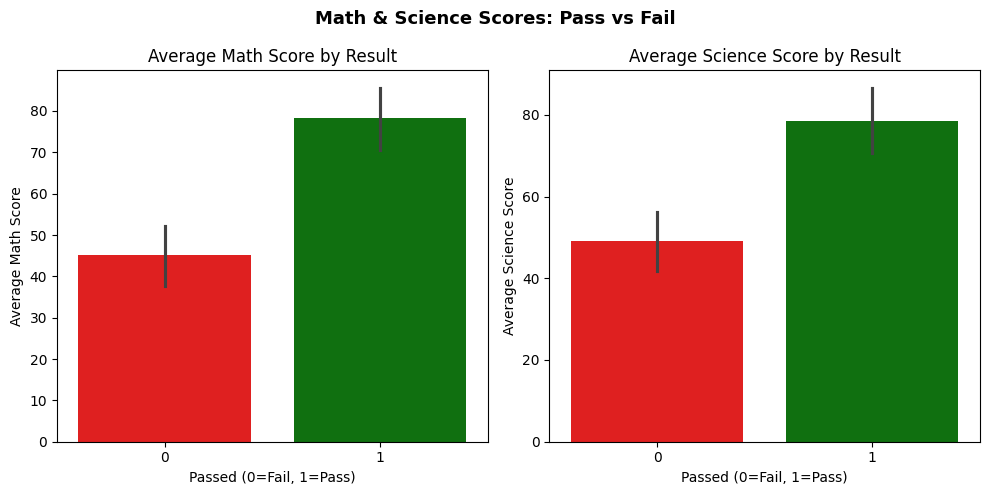

Saved: plot6_seaborn_bar.png


In [14]:
# Plot6 — Seaborn Bar Plot: avg math and science score, split by pass/fail
# Using plt.subplots() with two separate sns.barplot() calls as instructed

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Assign x to hue to avoid FutureWarning in newer seaborn versions
sns.barplot(data=df, x='passed', y='math',
            hue='passed', palette={0: 'red', 1: 'green'},
            legend=False, ax=ax1)
ax1.set_title("Average Math Score by Result")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Average Math Score")

sns.barplot(data=df, x='passed', y='science',
            hue='passed', palette={0: 'red', 1: 'green'},
            legend=False, ax=ax2)
ax2.set_title("Average Science Score by Result")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Average Science Score")

plt.suptitle("Math & Science Scores: Pass vs Fail", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png", dpi=150)
plt.show()
print("Saved: plot6_seaborn_bar.png")

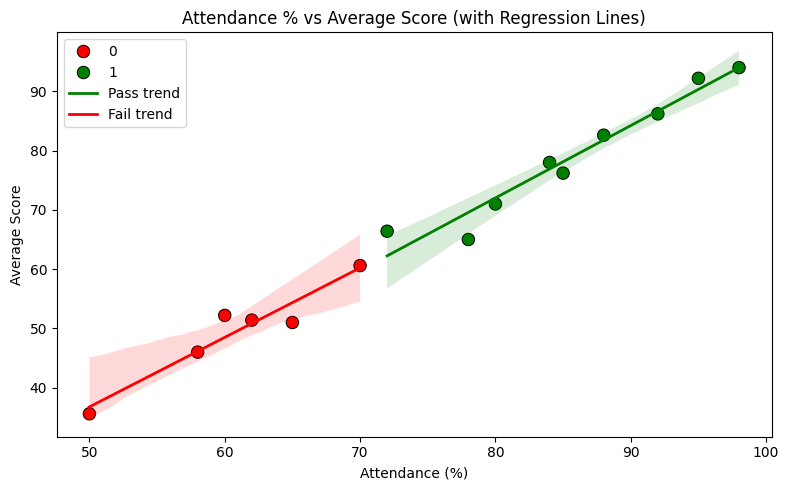

Saved: plot7_seaborn_scatter.png


In [15]:
# Plot7 — Seaborn Scatter + Regression: attendance_pct vs avg_score
plt.figure(figsize=(8, 5))

# Scatter points coloured by pass/fail using hue
sns.scatterplot(data=df, x='attendance_pct', y='avg_score',
                hue='passed', palette={1: 'green', 0: 'red'},
                s=80, edgecolor='black')

# Separate regression lines for each group
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            scatter=False, color='green', label='Pass trend',
            line_kws={'linewidth': 2})
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            scatter=False, color='red',   label='Fail trend',
            line_kws={'linewidth': 2})

plt.title("Attendance % vs Average Score (with Regression Lines)")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png", dpi=150)
plt.show()
print("Saved: plot7_seaborn_scatter.png")

In [16]:
# Seaborn vs Matplotlib — Reflection Comment
#
# Seaborn required significantly less code for grouped plots — the 'hue'
# parameter automatically split data by pass/fail and applied colour palettes,
# while Matplotlib required manually filtering two DataFrames and calling
# plt.scatter() twice. However, Matplotlib offered more precise control over
# individual elements (exact marker shapes, line styles, tick formatting),
# which was useful for the line and box plots in Task 2.

## Task 4 — Machine Learning with scikit-learn

In [17]:
# Step 1 — Prepare Data
# Features X: all 7 numeric columns (name and passed excluded)
# Target  y: passed column

X = df[['math', 'science', 'english', 'history', 'pe',
        'attendance_pct', 'study_hours_per_day']]
y = df['passed']

# 80/20 train-test split — random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Save test indices BEFORE scaling — needed later to look up student names
test_indices = X_test.index

# Scale features — fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training samples :", len(X_train))
print("Test samples     :", len(X_test))

Training samples : 12
Test samples     : 3


In [18]:
# Step 2 — Train Logistic Regression
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Print training accuracy
train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc * 100:.1f}%")

Training Accuracy: 100.0%


In [19]:
# Step 3 — Evaluate on the test set
y_pred = model.predict(X_test_scaled)

# Test accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc * 100:.1f}%")
print()

# Per-student prediction table with ✅ / ❌
print(f"{'Student':<10} | {'Actual':>6} | {'Predicted':>9} | Result")
print("-" * 42)

names = df.loc[test_indices, 'name']
for name, actual, pred in zip(names, y_test, y_pred):
    actual_label = "Pass" if actual == 1 else "Fail"
    pred_label   = "Pass" if pred   == 1 else "Fail"
    status       = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name:<10} | {actual_label:>6} | {pred_label:>9} | {status}")

Test Accuracy: 100.0%

Student    | Actual | Predicted | Result
------------------------------------------
Jack       |   Fail |      Fail | ✅ Correct
Liam       |   Fail |      Fail | ✅ Correct
Alice      |   Pass |      Pass | ✅ Correct


In [20]:
# Step 4 — Feature Importance: model coefficients
feature_names = X.columns.tolist()
coefficients  = model.coef_[0]

# Sort by absolute value — largest coefficient = most influential feature
coef_pairs = sorted(zip(feature_names, coefficients),
                    key=lambda x: abs(x[1]), reverse=True)

print("Feature Coefficients (sorted by absolute value):")
print(f"{'Feature':<25} | {'Coefficient':>12}")
print("-" * 42)
for feat, coef in coef_pairs:
    direction = "→ Push to Pass" if coef > 0 else "→ Push to Fail"
    print(f"{feat:<25} | {coef:>12.4f}  {direction}")

Feature Coefficients (sorted by absolute value):
Feature                   |  Coefficient
------------------------------------------
english                   |       0.8125  → Push to Pass
attendance_pct            |       0.5219  → Push to Pass
study_hours_per_day       |       0.4844  → Push to Pass
pe                        |       0.4750  → Push to Pass
math                      |       0.4379  → Push to Pass
science                   |       0.3230  → Push to Pass
history                   |       0.2629  → Push to Pass


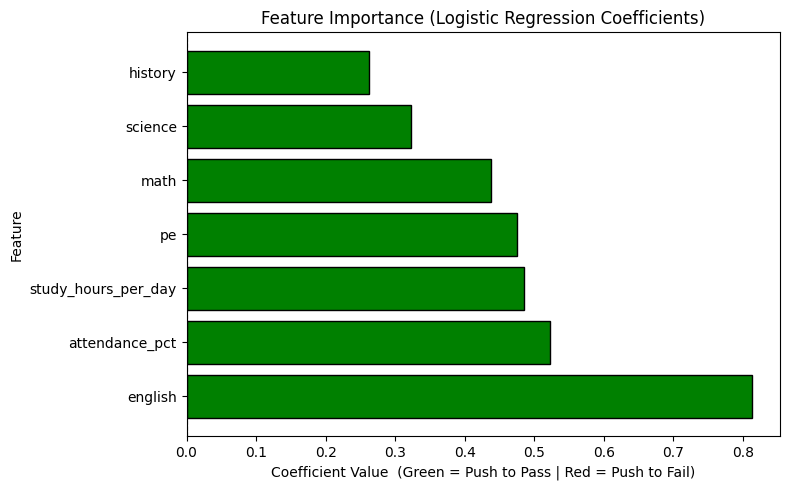

Saved: feature_importance.png


In [21]:
# Feature importance horizontal bar chart
# Green = positive coefficient (pushes prediction toward Pass)
# Red   = negative coefficient (pushes prediction toward Fail)

feats  = [p[0] for p in coef_pairs]
coefs  = [p[1] for p in coef_pairs]
colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure(figsize=(8, 5))
plt.barh(feats, coefs, color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value  (Green = Push to Pass | Red = Push to Fail)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Saved: feature_importance.png")

In [22]:
# Step 5 (Bonus) — Predict for a brand-new student
# Feature order must match: math, science, english, history, pe,
#                           attendance_pct, study_hours_per_day
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Use pd.DataFrame so the scaler recognises feature names (avoids warning)
new_df     = pd.DataFrame(new_student, columns=X.columns)
new_scaled = scaler.transform(new_df)

prediction = model.predict(new_scaled)[0]
proba      = model.predict_proba(new_scaled)[0]

result = "Pass ✅" if prediction == 1 else "Fail ❌"

print("New Student Prediction")
print("-" * 35)
print(f"Input features : {new_student[0]}")
print(f"Prediction     : {result}")
print(f"Probability    : Fail={proba[0]:.2%}  |  Pass={proba[1]:.2%}")

New Student Prediction
-----------------------------------
Input features : [75, 70, 68, 65, 80, 82, 3.2]
Prediction     : Pass ✅
Probability    : Fail=9.20%  |  Pass=90.80%
